# Лабораторная №1

In [34]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np


## 1. Случайный массив в NumPy и операции

In [35]:
arr = np.random.randint(10, 200, size=15)
arr

array([158, 137,  21,  82, 156, 120, 158, 165, 115, 113,  14,  48, 145,
       175,  82])

In [36]:
print('max =', arr.max())
print('min =', arr.min())
print('mean =', round(float(arr.mean()), 2))

max = 175
min = 14
mean = 112.6


In [37]:
A = arr.reshape(3, 5)
A

array([[158, 137,  21,  82, 156],
       [120, 158, 165, 115, 113],
       [ 14,  48, 145, 175,  82]])

In [38]:
print('Элемент [1, 3]:', A[1, 3])
print('Второй столбец как вектор:', A[:, 1].reshape(-1, 1))
print('Первая строка:', A[0, :])

Элемент [1, 3]: 115
Второй столбец как вектор: [[137]
 [158]
 [ 48]]
Первая строка: [158 137  21  82 156]


In [39]:
A[A > 100]

array([158, 137, 156, 120, 158, 165, 115, 113, 145, 175])

## 2. Выделение объектов с помощью OpenCV

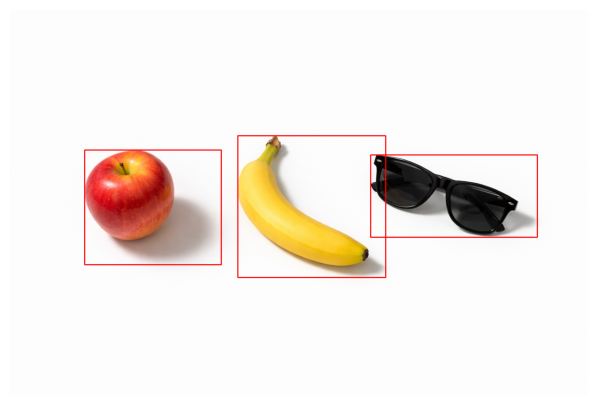

In [40]:
image_path = 'img.png'
image_arr = cv2.imread(image_path)

gray = cv2.cvtColor(image_arr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary_mask = cv2.threshold(blurred, 235, 255, cv2.THRESH_BINARY_INV)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=1)

contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_rgb = cv2.cvtColor(image_arr, cv2.COLOR_BGR2RGB)
for contour in contours:
    contour_area = cv2.contourArea(contour)
    if contour_area < 1200:
        continue

    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(9, 5))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()


## 3. Rectangle из OpenCV с нуля

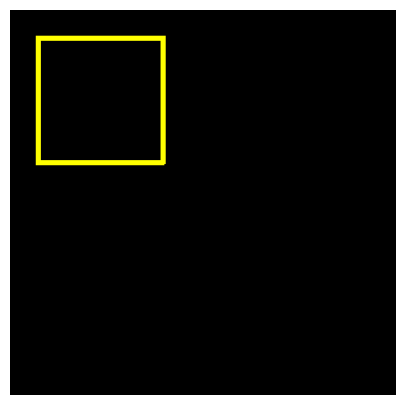

In [59]:
def my_rectangle(img, x, y, w, h, color, thickness=3):
    result = img.copy()
    
    for t in range(thickness):
        result[y+t, x:x+w] = color
        result[y+h-t, x:x+w] = color
        
        result[y:y+h, x+t] = color
        result[y:y+h, x+w-t] = color
    
    return result

img = np.zeros((300, 300, 3), dtype=np.uint8)

result = my_rectangle(img, 20, 20, 100, 100, [255, 255, 0], thickness=4)

plt.figure(figsize=(9, 5))
plt.imshow(result)
plt.axis('off')
plt.show()
